<a href="https://colab.research.google.com/github/LorenzoMedina-lab/CodePro_California_housing/blob/main/California_housing_defensa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de precios de viviendas en California

**Objetivo:** identificar qué características están más relacionadas con el precio de las viviendas en California mediante un análisis exploratorio de datos.

El notebook sigue el orden:

**exploración → limpieza/preprocesamiento → análisis simple → análisis multivariado**


In [ ]:
from google.colab import drive

# Montamos Google Drive para acceder al archivo CSV guardado allí.
drive.mount('/content/drive')


Mounted at /content/drive


## 1. Carga y exploración inicial

Antes de modificar los datos se verifican el tamaño del dataset, las columnas, los tipos de datos, los valores faltantes y algunas filas de ejemplo. Esta etapa permite detectar problemas antes de comenzar el análisis.


In [ ]:
# Librerías para manipulación, cálculo y visualización de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Estilo visual uniforme para todos los gráficos.
sns.set_theme(style="whitegrid")

# Ruta del archivo y carga del dataset.
ruta_archivo = '/content/drive/MyDrive/CodePro5.0/housing.csv/housing.csv'
df_california = pd.read_csv(ruta_archivo)

# shape devuelve la cantidad de filas y columnas.
print("Dimensiones:", df_california.shape)

# isnull().sum() cuenta los valores faltantes de cada columna.
print()
print("Valores faltantes:")
print(df_california.isnull().sum())

# duplicated().sum() verifica si existen filas completamente repetidas.
print()
print("Filas duplicadas completas:", df_california.duplicated().sum())

# Vista rápida de los primeros registros.
display(df_california.head(3))


Dimensiones: (20640, 10)

Valores faltantes:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Filas duplicadas completas: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [ ]:
# info() resume columnas, tipos de datos y cantidad de valores no nulos.
df_california.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
# describe() genera estadísticas descriptivas de las variables numéricas:
# cantidad, media, desviación estándar, mínimo, cuartiles y máximo.
display(df_california.describe())


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Qué observamos inicialmente

El dataset contiene **20.640 registros y 10 columnas**. La variable `total_bedrooms` contiene **207 valores faltantes** y `ocean_proximity` es la principal variable categórica.

Las variables más relevantes para la pregunta del desafío son:

- `median_house_value`: precio mediano de la vivienda.
- `median_income`: ingreso mediano de la zona.
- `housing_median_age`: edad mediana de las viviendas.
- `ocean_proximity`: cercanía al océano.
- `longitude` y `latitude`: ubicación geográfica.

**Idea clave:** `median_house_value` es la variable principal porque queremos descubrir qué características están asociadas con diferencias de precio.


## 2. Limpieza y preprocesamiento

El problema de calidad más evidente es la presencia de valores faltantes en `total_bedrooms`.

Los reemplazamos por la **mediana** porque es una medida robusta frente a valores extremos y nos permite conservar todos los registros. Por ahora mantenemos `ocean_proximity` como variable categórica para que los gráficos sean fáciles de interpretar.


In [ ]:
# Calculamos la mediana de total_bedrooms.
mediana_habitaciones = df_california['total_bedrooms'].median()

# fillna() reemplaza únicamente los valores faltantes de la columna.
df_california['total_bedrooms'] = (
    df_california['total_bedrooms']
    .fillna(mediana_habitaciones)
)

# Verificamos que la limpieza haya eliminado los valores nulos.
print('Valores faltantes después de la limpieza:')
print(df_california.isnull().sum())


Valores faltantes después de la limpieza:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## 3. Distribución individual del precio

**Pregunta:** ¿Cómo se distribuyen los precios de las viviendas en California?

Utilizamos un histograma porque permite observar la frecuencia de los distintos rangos de precio y detectar concentraciones o valores poco habituales.


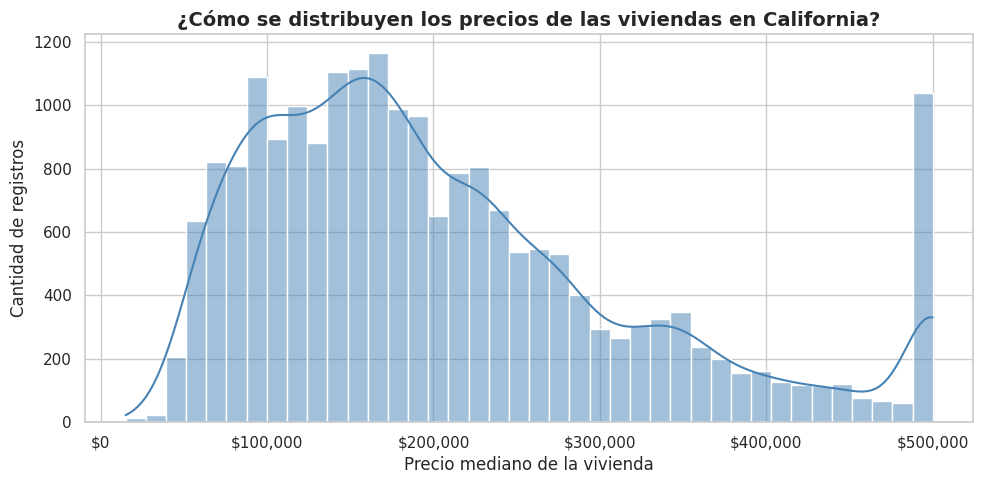

In [ ]:
# Histograma del precio mediano de las viviendas.
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_california,
    x='median_house_value',
    bins=40,          # Divide el rango de precios en 40 intervalos.
    kde=True,         # Agrega una curva suavizada de la distribución.
    color='steelblue'
)

plt.title(
    '¿Cómo se distribuyen los precios de las viviendas en California?',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Precio mediano de la vivienda')
plt.ylabel('Cantidad de registros')

# Mostramos el eje X como valores monetarios para facilitar la lectura.
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

plt.tight_layout()
plt.show()


**Interpretación:** La mayor cantidad de registros se concentra aproximadamente entre **USD 80.000 y USD 250.000**. A medida que aumenta el precio, la frecuencia disminuye. También aparece una concentración notable alrededor de los **USD 500.000**.

**Conclusión:** Los precios no presentan una distribución uniforme. La acumulación observada en el extremo superior sugiere que el dataset podría tener un límite máximo de registro cercano a USD 500.000.


## 4. Distribución del precio según la cercanía al océano

**Pregunta:** ¿La ubicación respecto al océano está asociada con diferencias en el precio?

Usamos un **boxplot** porque permite comparar la mediana, la dispersión y los valores atípicos del precio entre distintas categorías de ubicación.


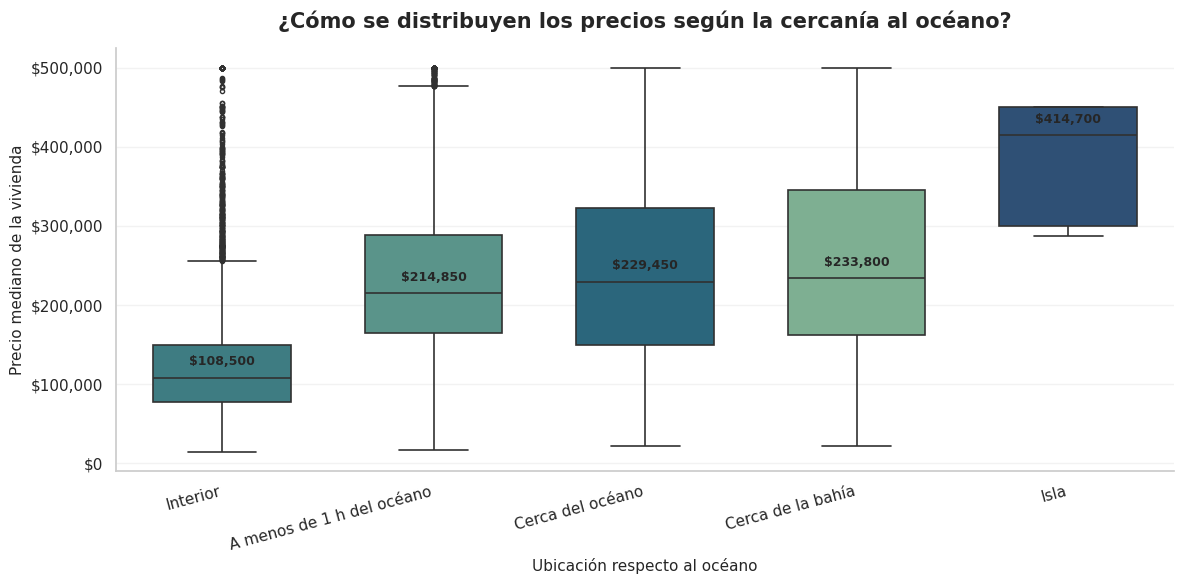

In [ ]:
# Se traducen las categorías únicamente para mostrarlas con nombres más claros.
nombres_zonas = {
    'INLAND': 'Interior',
    '<1H OCEAN': 'A menos de 1 h del océano',
    'NEAR OCEAN': 'Cerca del océano',
    'NEAR BAY': 'Cerca de la bahía',
    'ISLAND': 'Isla'
}

# Se crea una columna auxiliar para visualización sin modificar ocean_proximity.
df_california['zona'] = df_california['ocean_proximity'].map(nombres_zonas)

# Ordenamos las categorías para facilitar la comparación visual.
orden_zonas = [
    'Interior',
    'A menos de 1 h del océano',
    'Cerca del océano',
    'Cerca de la bahía',
    'Isla'
]

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df_california,
    x='zona',
    y='median_house_value',
    order=orden_zonas,
    hue='zona',
    palette='crest',
    legend=False,
    width=0.65,
    linewidth=1.2,
    fliersize=3
)

# Calculamos la mediana de cada categoría y la mostramos sobre su caja.
medianas = (
    df_california
    .groupby('zona')['median_house_value']
    .median()
    .reindex(orden_zonas)
)

for i, valor in enumerate(medianas):
    ax.text(
        i,
        valor + 12000,
        f'${valor:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    '¿Cómo se distribuyen los precios según la cercanía al océano?',
    fontsize=15,
    fontweight='bold',
    pad=15
)
plt.xlabel('Ubicación respecto al océano', fontsize=11)
plt.ylabel('Precio mediano de la vivienda', fontsize=11)

# Formato monetario del eje Y.
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.xticks(rotation=15, ha='right')
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', visible=False)
sns.despine()

plt.tight_layout()
plt.show()


La línea dentro de cada caja representa la **mediana**. La caja contiene aproximadamente el 50 % central de los registros. Los bigotes muestran el rango habitual según la regla del boxplot y los puntos separados representan valores atípicos estadísticos, no necesariamente errores.

**Conclusión:** Las zonas del **interior** presentan los precios medianos más bajos. Las zonas cercanas al océano y a la bahía muestran valores considerablemente mayores. La categoría **Isla** presenta la mediana más alta, aunque debe interpretarse con cautela por su menor cantidad de observaciones.

**Importante:** El gráfico muestra una asociación entre ubicación y precio; no demuestra causalidad.


## 5. Relación entre ingreso y precio

**Pregunta:** ¿Existe relación entre el ingreso mediano de una zona y el precio mediano de sus viviendas?

Usamos un **scatterplot** porque permite observar la relación entre dos variables numéricas y detectar tendencias, dispersión y posibles límites en los datos.


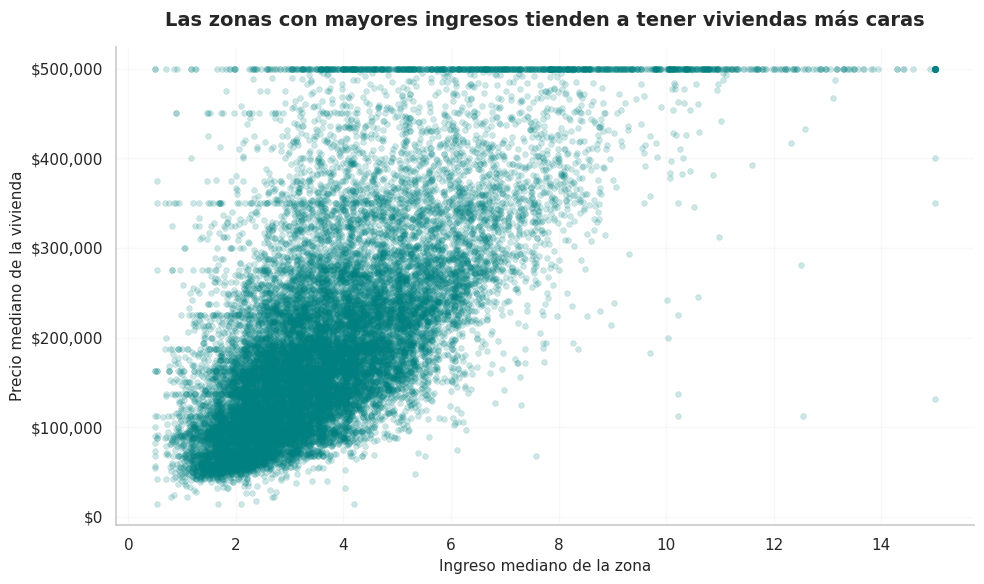

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_california,
    x='median_income',
    y='median_house_value',
    alpha=0.20,       # Transparencia para reducir la superposición de puntos.
    color='teal',
    s=18,
    edgecolor=None
)

plt.title(
    'Las zonas con mayores ingresos tienden a tener viviendas más caras',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel('Ingreso mediano de la zona', fontsize=11)
plt.ylabel('Precio mediano de la vivienda', fontsize=11)

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.grid(alpha=0.12)
sns.despine()
plt.tight_layout()
plt.show()


**Interpretación:** Cada punto representa una zona del dataset. En el eje X se encuentra el ingreso mediano y en el eje Y el precio mediano de la vivienda. La nube de puntos muestra una **tendencia positiva**: los precios tienden a aumentar cuando aumenta el ingreso mediano.

**Conclusión:** Existe una asociación positiva entre ingreso y precio, pero la dispersión indica que el ingreso no explica por sí solo todas las diferencias de precio.

**Nota:** `median_income` se mantiene en la escala original del dataset; valores mayores representan zonas con mayores ingresos medianos.

**Observación:** La concentración de puntos cerca de los USD 500.000 vuelve a sugerir un posible límite superior en los precios registrados.


## 6. Correlación entre variables

**Pregunta:** ¿Qué características numéricas están más relacionadas linealmente con el precio?

La correlación toma valores entre **-1 y 1**:

- cercano a **1**: relación lineal positiva fuerte;
- cercano a **-1**: relación lineal negativa fuerte;
- cercano a **0**: poca relación lineal.

**Importante:** correlación no implica causalidad.


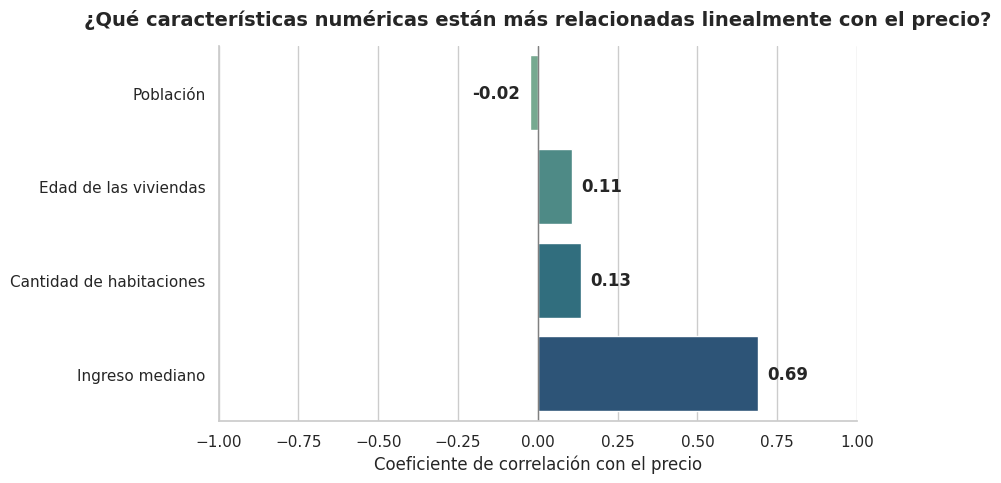

In [ ]:

# Seleccionamos únicamente las variables numéricas
# que queremos comparar con el precio de las viviendas.
variables_clave = [
    'median_house_value',
    'median_income',
    'housing_median_age',
    'total_rooms',
    'population'
]

# Calculamos la correlación de cada variable con el precio.
# Eliminamos median_house_value porque su correlación
# consigo misma siempre sería 1.
correlacion_precio = (
    df_california[variables_clave]
    .corr()['median_house_value']
    .drop('median_house_value')
    .sort_values()
)

# Cambiamos los nombres técnicos por nombres
# más fáciles de interpretar para el usuario.
nombres_variables = {
    'median_income': 'Ingreso mediano',
    'housing_median_age': 'Edad de las viviendas',
    'total_rooms': 'Cantidad de habitaciones',
    'population': 'Población'
}

correlacion_precio.index = (
    correlacion_precio.index.map(nombres_variables)
)

# Creamos el gráfico.
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=correlacion_precio.values,
    y=correlacion_precio.index,
    hue=correlacion_precio.index,
    palette='crest',
    legend=False
)

# La línea en cero permite diferenciar fácilmente
# correlaciones positivas y negativas.
plt.axvline(
    0,
    color='gray',
    linewidth=1
)

plt.title(
    '¿Qué características numéricas están más relacionadas linealmente con el precio?',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Coeficiente de correlación con el precio')
plt.ylabel('')

# Los coeficientes de correlación están entre -1 y 1.
plt.xlim(-1, 1)

# Mostramos el valor exacto para facilitar la interpretación.
for i, valor in enumerate(correlacion_precio.values):

    ax.text(
        valor + 0.03 if valor >= 0 else valor - 0.03,
        i,
        f'{valor:.2f}',
        va='center',
        ha='left' if valor >= 0 else 'right',
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

Interpretación: El gráfico compara la correlación lineal de distintas características con el precio mediano de las viviendas. Los valores positivos indican que ambas variables tienden a aumentar juntas, mientras que los valores próximos a cero indican poca relación lineal.

Conclusión: El ingreso mediano presenta claramente la mayor relación positiva con el precio, con una correlación aproximada de 0,69. La cantidad total de habitaciones y la edad de las viviendas presentan relaciones mucho más débiles, mientras que la población muestra prácticamente ninguna relación lineal con el precio.

## 7. Pairplot de variables clave

**Pregunta:** ¿Qué patrones aparecen cuando comparamos varias variables importantes entre sí?

El pairplot permite observar en la diagonal la distribución individual de cada variable y, fuera de la diagonal, la relación entre pares de variables. Usamos una muestra de **1.000 registros** únicamente para mejorar la legibilidad y el tiempo de renderizado.


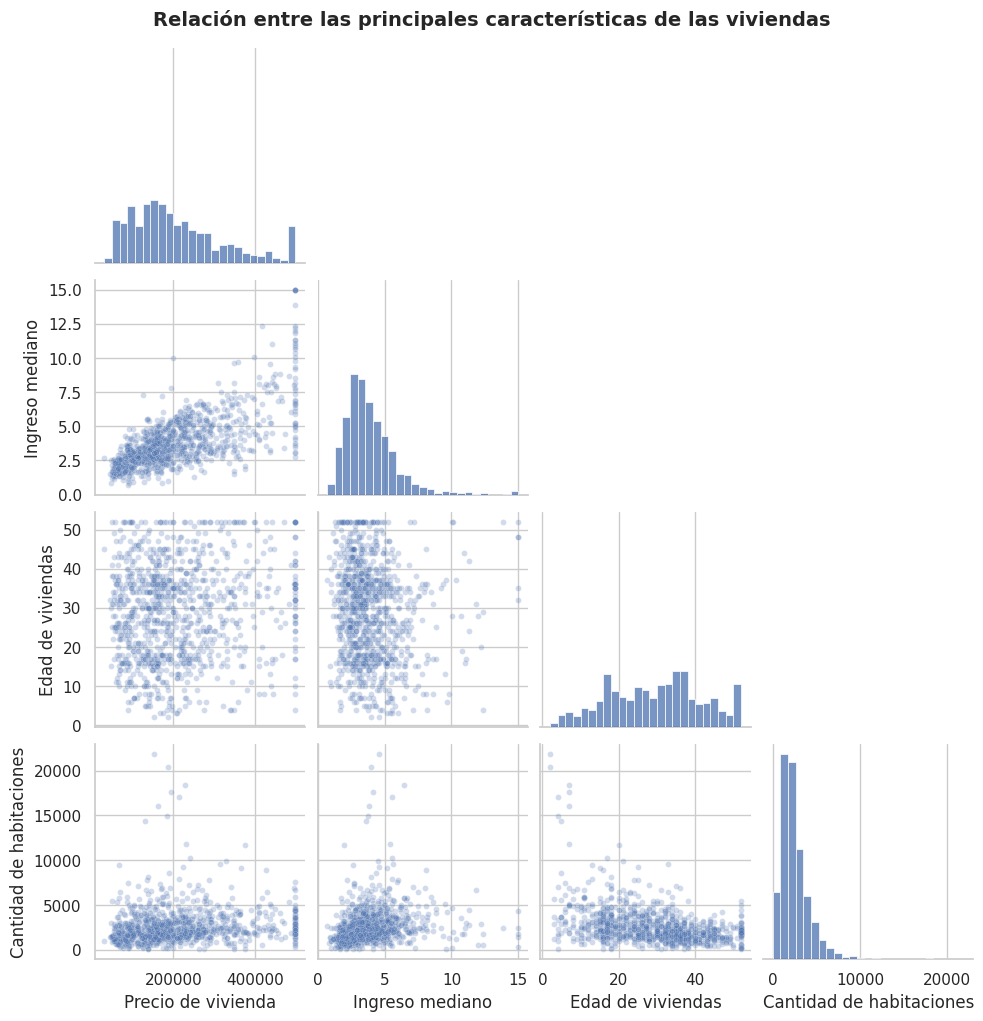

In [ ]:
# Variables principales para comparar.
columnas_clave = [
    'median_house_value',
    'median_income',
    'housing_median_age',
    'total_rooms'
]

# sample() toma una muestra reproducible para visualizar sin modificar el dataset original.
muestra_df = (
    df_california[columnas_clave]
    .sample(n=1000, random_state=42)
)

# Renombramos columnas únicamente para que el gráfico sea fácil de leer.
muestra_visual = muestra_df.rename(columns={
    'median_house_value': 'Precio de vivienda',
    'median_income': 'Ingreso mediano',
    'housing_median_age': 'Edad de viviendas',
    'total_rooms': 'Cantidad de habitaciones'
})

sns.pairplot(
    muestra_visual,
    corner=True,        # Oculta la mitad superior porque sería información repetida.
    diag_kind='hist',
    plot_kws={'alpha': 0.25, 's': 18},
    diag_kws={'bins': 25}
)

plt.suptitle(
    'Relación entre las principales características de las viviendas',
    y=1.02,
    fontsize=14,
    fontweight='bold'
)
plt.show()


**Interpretación:** En la diagonal se observa la distribución de cada variable. En las demás celdas se observa la relación entre pares. La relación visual más clara aparece entre **ingreso mediano y precio de vivienda**, donde se aprecia una tendencia ascendente. La edad de las viviendas y la cantidad total de habitaciones presentan mayor dispersión respecto al precio.

**Conclusión:** El pairplot confirma visualmente que el ingreso mediano tiene una relación más clara con el precio que las otras variables seleccionadas.

La muestra de 1.000 registros se utiliza solo para visualización y no reemplaza ni modifica el dataset original.


## 8. Análisis multivariado: ingreso, precio y cercanía al océano

**Pregunta:** ¿La relación entre ingreso y precio se comporta igual en todas las zonas o la ubicación también aporta información?

Combinamos tres variables:

- ingreso mediano (`median_income`);
- precio mediano (`median_house_value`);
- ubicación respecto al océano (`zona`).



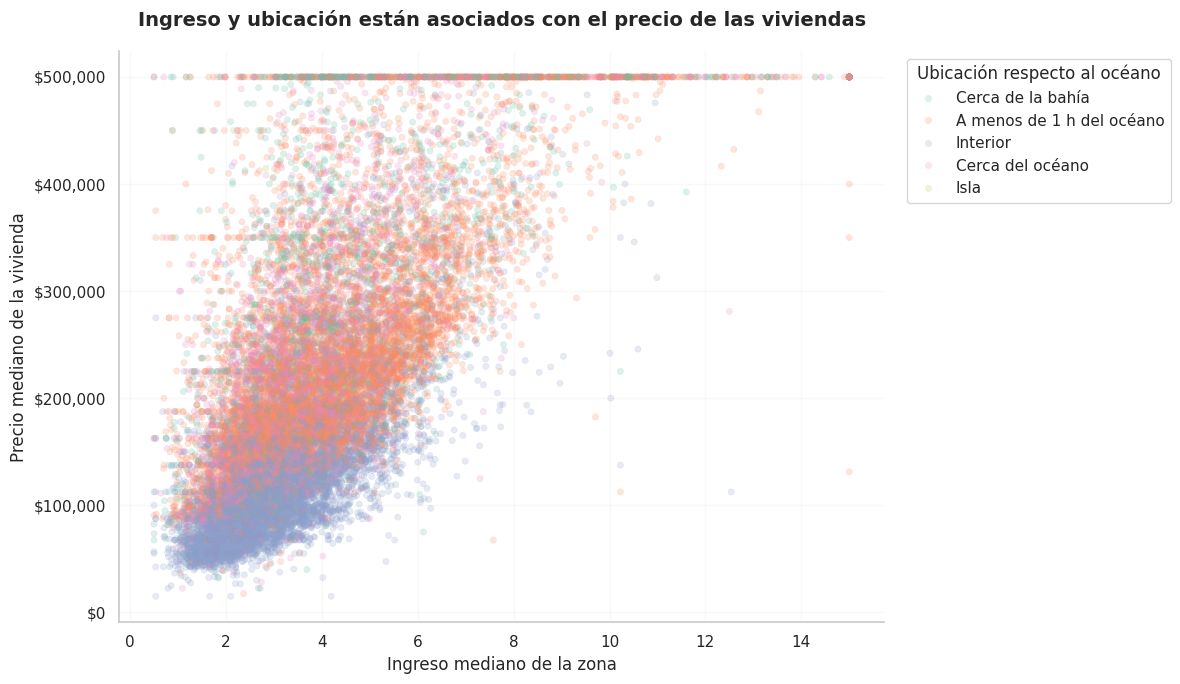

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df_california,
    x='median_income',
    y='median_house_value',
    hue='zona',
    palette='Set2',
    alpha=0.22,
    s=20,
    edgecolor=None,
    ax=ax
)

ax.set_title(
    'Ingreso y ubicación están asociados con el precio de las viviendas',
    fontsize=14,
    fontweight='bold',
    pad=18
)
ax.set_xlabel('Ingreso mediano de la zona')
ax.set_ylabel('Precio mediano de la vivienda')

# Formato monetario del eje Y.
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# Colocamos la leyenda fuera del área principal para no tapar los datos.
ax.legend(
    title='Ubicación respecto al océano',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.grid(alpha=0.12)
sns.despine()
plt.tight_layout()
plt.show()


**Interpretación:** La tendencia positiva entre ingreso y precio continúa siendo visible. Sin embargo, los colores muestran que para niveles de ingreso similares pueden existir diferencias de precio según la ubicación. Los registros del **interior** se concentran con mayor frecuencia en precios bajos, mientras que las zonas próximas al océano aparecen más a menudo en precios elevados.

**Conclusión:** El ingreso mediano es una característica importante, pero la ubicación también aporta información para entender las diferencias de precio. El mercado de viviendas es multivariable y no puede explicarse únicamente con una sola característica.

**Importante:** El gráfico muestra asociaciones entre las variables, no relaciones causales.


## 9. Conclusiones generales

El análisis exploratorio responde la pregunta principal sin utilizar modelos predictivos.

- Los precios se concentran principalmente en rangos bajos y medios, con una acumulación llamativa alrededor de USD 500.000.
- La cercanía al océano está asociada con diferencias importantes de precio: las zonas del interior presentan precios medianos considerablemente menores.
- El ingreso mediano presenta la relación lineal positiva más fuerte con el precio entre las variables numéricas seleccionadas, con una correlación aproximada de 0,69.
- La edad de las viviendas, la cantidad total de habitaciones y la población muestran relaciones lineales mucho más débiles con el precio.
- El análisis multivariado muestra que ingreso y ubicación aportan información complementaria.
- Los gráficos muestran **asociaciones y patrones**, pero no demuestran causalidad.

### Idea central

La historia del notebook avanza desde una pregunta simple —**cómo se distribuyen los precios**— hasta una pregunta multivariada —**cómo se relacionan ingreso, precio y ubicación**—. Cada gráfico tiene una pregunta concreta y fue elegido para responderla de la forma más clara posible.
